# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [3]:
titanic = pd.read_csv("/home/_coraina_/Desktop/titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


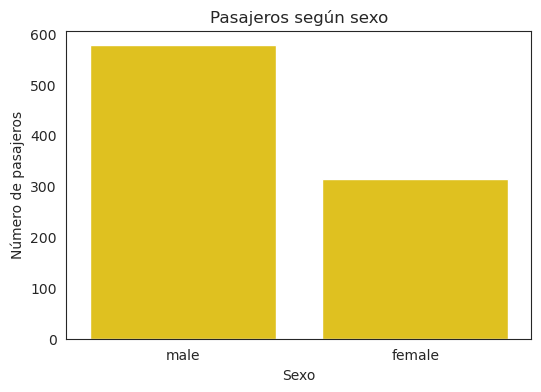

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


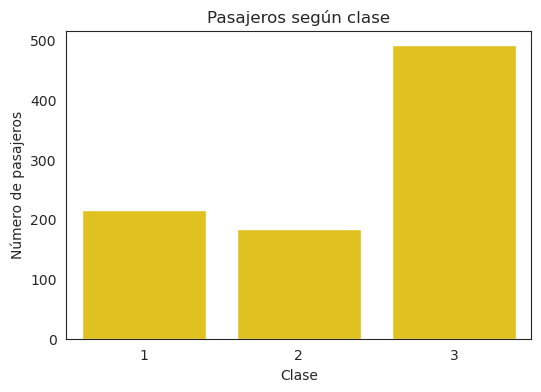

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="gold")

plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()
#Hay mayor cantidad de pasajeros en la clase 3, luego le sigue la clase 1, y hay una menor cantidad de pasajeros en la clase 2.
#No está tan balanceada, ya que la diferencia entre la clase 3 y las demás es considerable. 

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


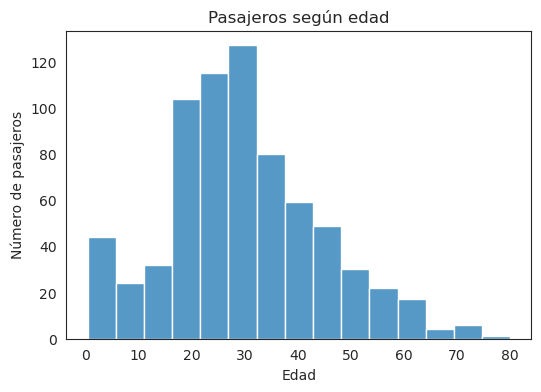

In [10]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=15)

plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()
#Las edades más frecuentes son entre los 18 y 35 años.
#La distribución a simple vista se ve simétrica, ya que la mayor cantidad se concentra en el centro y disminuye hacia ambos lados.
#La cantidad de bins no cambia mucho la interpretación pero si logra visualizar mejor en menores rangos de edad. 

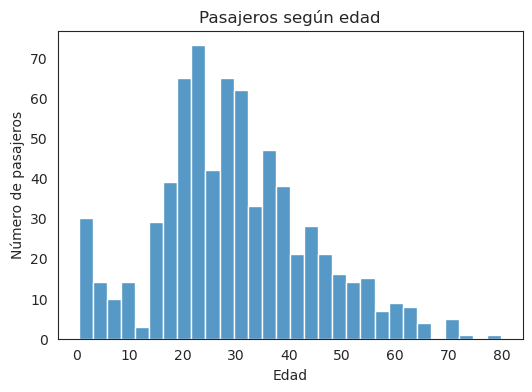

In [11]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=30)

plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()

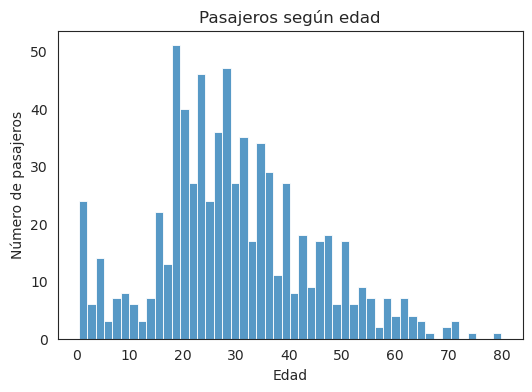

In [12]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=50)

plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()

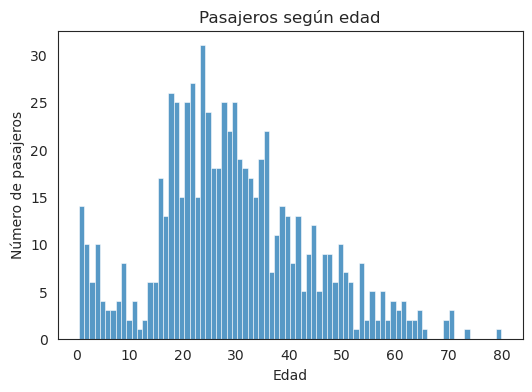

In [13]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Age", bins=80)

plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según edad")

plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


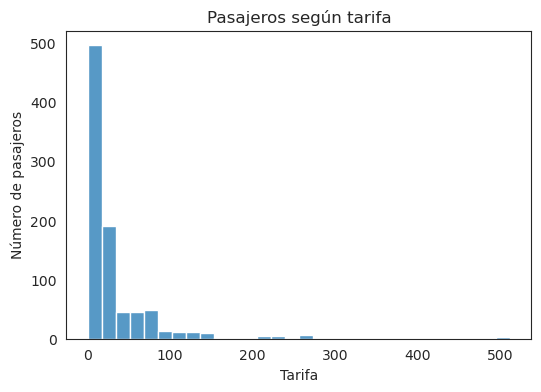

In [14]:
plt.figure(figsize=(6,4))

sns.histplot(data=titanic, x="Fare", bins=30)

plt.xlabel("Tarifa")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según tarifa")

plt.show()
#La distribución no es geométrica, la mayor cantidad de datos se concentra en menores valores, es decir, la mayoria de las personas pagaron
# menos dinero por sus boletos, y muy pocas personas pagaron boletos más caros. 
#Si, la mayoría de las tarifas son entre 0 y 100, y luego unas muy pocas superan los 200 y hasta los 500. 
#Puede significar que los datos de boletos muy caros son outlayers y pueden perturban el valor de la media, que dejaría de ser representativa.

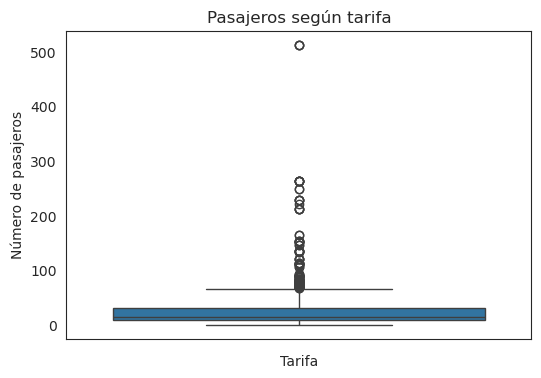

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(data=titanic, y="Fare")

plt.xlabel("Tarifa")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según tarifa")

plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [16]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


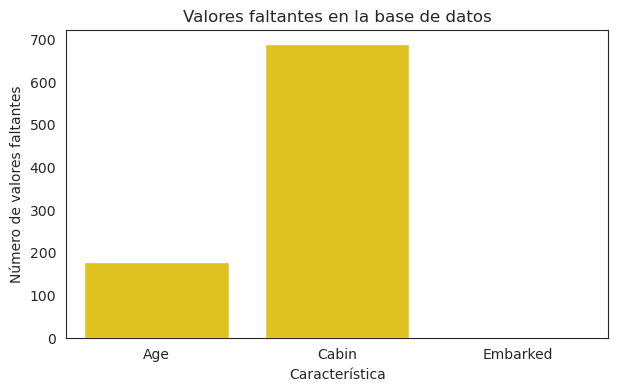

In [17]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [18]:
titanic.Age.mean()

np.float64(29.69911764705882)

In [19]:
titanic.Age.median()

np.float64(28.0)

In [20]:
#La media y la mediana son bastante similares
#Si bien, la media no es una mala reprensentación de la edad típica, tampoco es la mejor, ya que la edad típica,
# según los histogramas anteriores, es 24.

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


In [21]:
#No, ya que podría cambiar la que es en realidad la edad típica.
#La edad típica podría ser ahora igual a la media, pero la distribución seguiría siendo simétrica.
#Remplazar las edades faltantes por la edad típica.

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


In [22]:
#No intentaría rellenarlos, ya que al ser todas las cabinas distintas, la probabilidad de acertar es baja. 
#Creo que es mejor eliminarla a rellenarla.
#Podría contener información, para saber que tan lejos estaban las cabinas de las vías de escape, suponiendo que todas 
# las personas estaban en sus cabinas, lo cúal no debió ser realmente así. 

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


In [23]:
#Rellenar los datos de Embarked con datos aleatorios ya que podrían tomar solo dos valores. 
#Para Cabin todas las cabinas son distintas y es más difícil acertar, para Embarked son solo dos tipos y es más fácil acertar.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


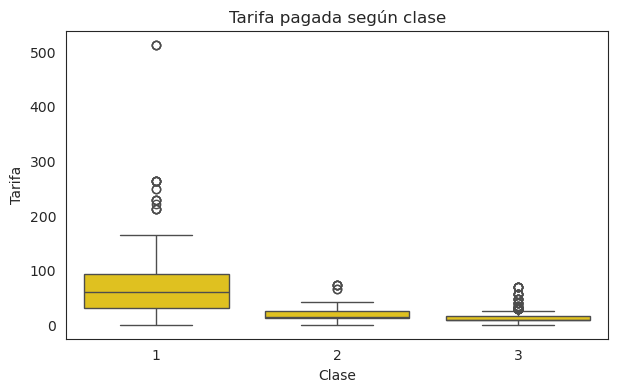

In [24]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


In [26]:
#Si parece estar relacionada, ya que en la clase 1, las tarifas son notablemente mayores.
#Si,la clase 1 muestra una gran dispersión, lo que indica una considerable variación en lo que pagó cada pasajero.
#Por otro lado las clases 2 y 3, muestran menos dispersión ya que los valores son más concentrados. 
#Si existen valores extremos, representados por los circulos fuera de los bigotes del diagrama de caja.
#Fare y Pclass no contienen la misma información, Fare es una variable cuantitativa continua y Pclass es una variable cualitativa ordinal, 
# por lo tanto, no se puede predecir la tarifa solo sabiendo la clase.

### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


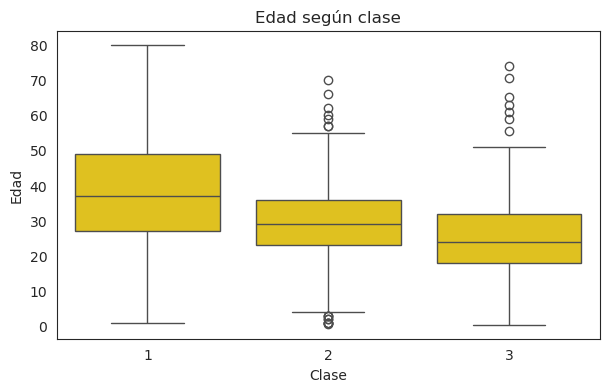

In [28]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Age", color='gold')

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad según clase")

plt.show()
#No tienen edades similares en todas las clases, en la clase 1 la mediana es 37-38 años, en la clase 2 la mediana es 29-30 años 
# y en la clase 3 la mediana es 24 años, esto quiere decir que a menor clase, menor es la edad de los pasajeros.
#En la clase 1, el rango intercuartil es mayor que en las demás clases, pero la clase 2 y 3 tienen más valores átipicos que la clase 1.

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [33]:
titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1

**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


In [35]:
#La mayoria de los pasajeros viajaba solo, siendo 537.
#Si hay grupos familiares muy grandes, hay grupos de 5, 6, 7, 8 y hasta 11 integrantes.
#Si cambíaria por que no veríamos los integrantes de toda la familia, si no que veríamos padres y hermanos por separado.

In [36]:
titanic["Familia"].value_counts().sort_index()

Familia
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


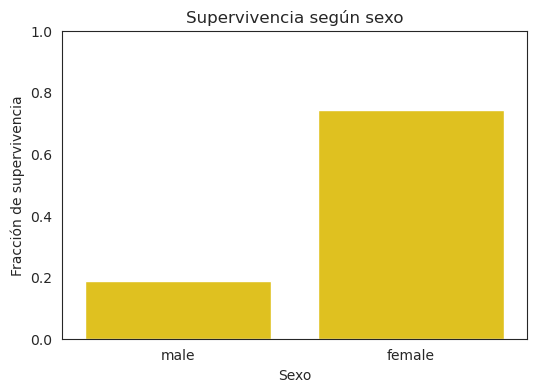

In [37]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


In [ ]:
#No, sobrevió una mayor fracción de mujeres que fracción de hombres. 
#No se puede concluir por qué debido a que no se muestran más factores además de la fracción por sexo. 

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


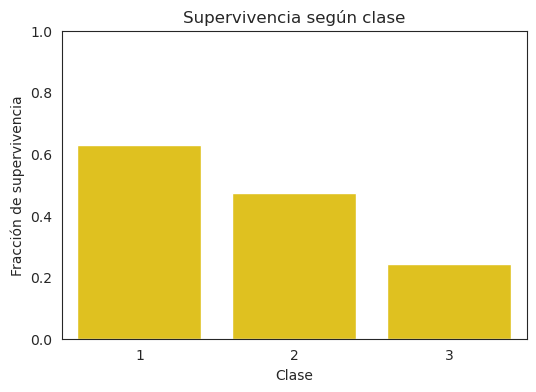

In [38]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='gold')

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()
#Si hay diferencia por clase, sobrevivió una mayor fracción en la clase 1, luego le sigue la clase 2 y sobrevivió una menor 
# fracción en la clase 3.
#Si existe una tendencia, a menor número de clase, mayor es la fracción de sobrevivientes 

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


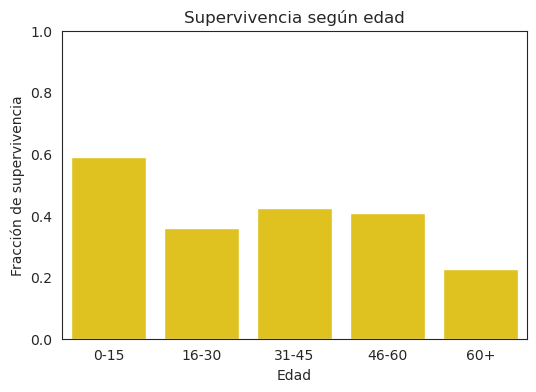

In [45]:
plt.figure(figsize=(6,4))
edades_bins = pd.cut(
    titanic["Age"], 
    bins=[0, 15, 30, 45, 60, 80], 
    labels=['0-15', '16-30', '31-45', '46-60', '60+']
)

sns.barplot(data=titanic, x=edades_bins, y="Survived", errorbar=None, color='gold')

plt.xlabel("Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según edad")
plt.ylim(0,1)

plt.show()
#La edad si parece estar asociada con la supervivencia, los menores de 15 años fueron los que más sobrevivieron, 
# mientras que los mayores de 60 años fueron los que menos sobrevivieron.

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


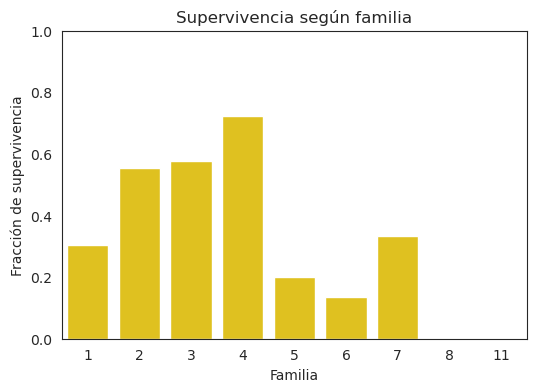

In [47]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='gold')

plt.xlabel("Familia")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según familia")
plt.ylim(0,1)

plt.show()
#Viajar solo parece desfavorable ya que la fracción de supervivientes que viajaban solos es baja en comparación con las familias.
#La relación no parece simple ni lineal, ya que baja, luego sube y luego vuelve a bajar. 
#Para los grupos familiares de más de 5 integrantes la fracción de supervivientes es más baja.

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


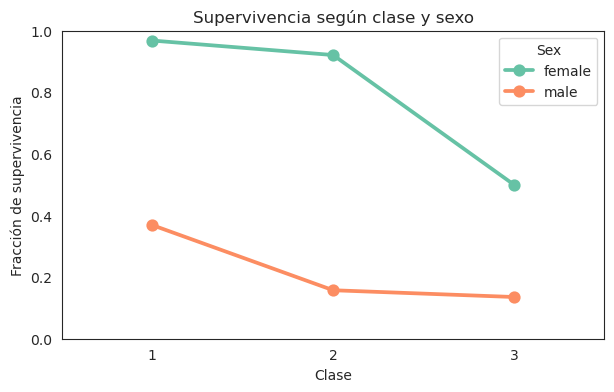

In [48]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



In [49]:
#La relación no es igual para hombres y mujeres, para las mujeres la supervivencia se mantiene alta entre la clase 1 y 2, 
# luego cae en la clase 3. Para los hombres la caída ocurre al pasar de clase 1 a clase dos, manteniendosé en clase 3.
#Se ocultaba el sesgo de género, por ejemplo, no se sabía que una mujer de clase 3 tenía más posibilidades de sobrevivir que un hombre
# de clase 1. 
#Se perdía la información de el impacto del nivel de la clase, por ejemplo, las mujeres de clase 3 tenían menos posibilidades de sobrevivir, 
# que las mujeres de clase 1 o 2.
#Si, el grupo favorecido son las mujeres de clase 1 y 2, con más del 90% de supervivencia, y el grupo desfavorecido son los hombres
# de clase 2 y 3, con menos del 20% de supervivencia. 

### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [51]:
titanic["Persona"] = np.where(titanic["Age"] < 16, "niño/a", np.where(titanic["Sex"] == "female", "mujer", "hombre"))

titanic["Persona"].value_counts()


Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


In [ ]:
#No del todo, la supervivencia para los niños si se parece a la de las mujeres pero no a la de los hombres.
#La clase sigue siendo importante dentro de cada grupo, siendo la clase 1 y 2 con más supervivientes en cualquier persona.
#Ser mujer y niño de clase 1 y 2.

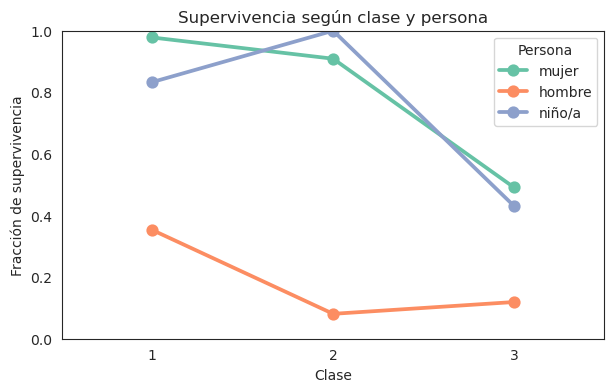

In [54]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",     
              hue="Persona",    
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y persona")
plt.ylim(0,1)

plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


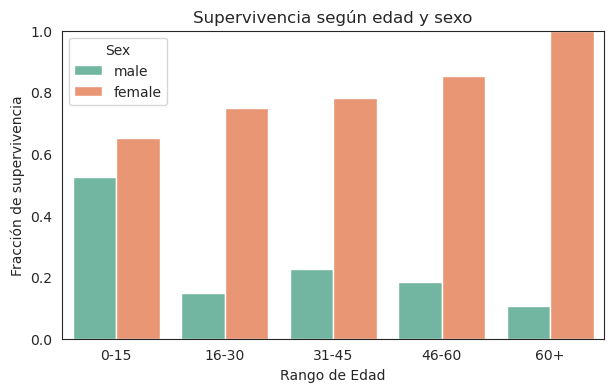

In [55]:
# Pregunta: ¿Cómo afecta a la edad en la superviviencia y en qué medida varía entre hombres y mujeres?
#El sexo fue el factor determinante por encima de la edad: las mujeres tuvieron una ventaja clara en todos los grupos etarios, 
# con una supervivencia que aumentó a mayor edad. Para los hombres, en cambio, la edad solo favoreció a los niños, 
# mientras que para los jóvenes y adultos las posibilidades de salvarse fueron muy bajas.

titanic["Rango_Edad"] = pd.cut(titanic["Age"], 
                               bins=[0, 15, 30, 45, 60, 80], 
                               labels=['0-15', '16-30', '31-45', '46-60', '60+'])

plt.figure(figsize=(7, 4))

sns.barplot(data=titanic, 
            x="Rango_Edad", 
            y="Survived", 
            hue="Sex", 
            palette="Set2", 
            errorbar=None)

plt.xlabel("Rango de Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según edad y sexo")
plt.ylim(0, 1)

plt.show()


# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


In [ ]:
#1. La muestra eran hombres y mujeres en las clases 1, 2 y 3, desde niños a adultos mayores, pasajeros solos y en familias.
# La mayor parte de la muestra esta compuesta por hombres adultos en clase 3 que viajaban solos.
#2. Ser mujer, estar en clase 1 y 2, los menores de 15 años y viajar en familias de 2 a 4 miembros. 
#3. Al analizar la relación clase, sexo y supervivencia o edad, sexo y supervivencia, se evidenció que la supervivencia no era similar 
# para ambos sexos, tampoco para las distintas clases, ni para todas las edades.
#4. Las variables de hermanos/conyuges y padres/hijos se relacionaron para crear la variable familia. 
#5. La observación es que los niños de clase 2 sobrevivieron en mayor fracción que los niños de clase 1, y mi hipótesis es que 
# las vías de evacuación estaban más lejos para los niños de clase 1.

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


In [ ]:
#El pasajero típico que sobrevivio fueron mujeres más jovenes y niños de clase 1 y 2, en grupos familiares de 2 a 4 personas.